### Libs

In [1]:
import os

import seaborn as sns
import torch
from dotenv import load_dotenv

load_dotenv(dotenv_path="../.env")

True

In [2]:
import trimesh

# Add the cloned 'shape' repo folder to your python path
from shape_foundation.configs.default import load_config
from shape_foundation.data.preprocessing import MeshPreprocessor
from shape_foundation.data.sampling import SurfaceSampler
from shape_foundation.models.gaot_backbone import GAOTBackbone
from shape_foundation.training.losses import LossComputer, compute_raw_geo_stats_dim

### Downloading Dataset

In [3]:
HF_TOKEN = os.getenv("HF_READ_TOKEN")
REPO_ID = "bayang/shape-foundation-small-v3"
LOCAL_DIR = os.path.join("checkpoints/shape-fm-small-v3")
METADATA_DIR = os.path.join("..", "pump_metadata")

### SHAPE FM Download

In [ ]:
# Download model files
# model_dir = snapshot_download(
#     repo_id=REPO_ID,
#     local_dir=LOCAL_DIR
# )
# print(f"Model downloaded to: {model_dir}")


Fetching 7 files:   0%|          | 0/7 [00:00<?, ?it/s]

Model downloaded to: /home/vpspepe/Documents/TUD/HiWi/EcoTwin/POC_Tests/SHAPE_Encoder/checkpoints/shape-fm-small-v3


#### Available Pump STL files

In [4]:
def collect_stl_files_walk(folder_path="."):
    """Returns a list of full file paths for all .stl files."""
    stl_files = []
    samples = []
    for root, dirs, files in os.walk(folder_path):
        for file in files:
            if file.lower().endswith(".stl"):
                stl_files.append(os.path.join(root, file))
                samples.append(root.split("/")[-1])
    return stl_files, samples


stl_files, samples = collect_stl_files_walk(METADATA_DIR)

In [5]:
selected_folders = [
    "sample_000019",
    "sample_000022",
    "sample_000063",
    "sample_000107",
    "sample_000132",
]

selected_folders = samples[::10]

### Loading Model

In [6]:
config_yaml = os.path.join(LOCAL_DIR, "small.yaml")
checkpoint_pt = os.path.join(LOCAL_DIR, "checkpoint_final.pt")
print("Loading configuration...")
config = load_config(config_yaml)
# Bypass torch-cluster requirement using native PyTorch fallback search
config.tokenizer.neighbor.backend = "native"
# Setup device and model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = GAOTBackbone(config).to(device)
print(f"Loading checkpoint weights onto {device}...")
checkpoint = torch.load(checkpoint_pt, map_location=device, weights_only=False)
model.load_state_dict(checkpoint["model_state_dict"])

Loading configuration...
Loading checkpoint weights onto cuda...


<All keys matched successfully>

## Eval Model

###  Loading meshes

In [7]:
mesh_dict = {}
for folder in selected_folders:
    stl_path = os.path.join(METADATA_DIR, folder, "merged_surfaces.stl")
    mesh = trimesh.load(stl_path)
    if isinstance(mesh, trimesh.Scene):
        mesh = mesh.dump(concatenate=True)
    mesh_dict[folder] = mesh

### Check similarity between embeddings of different geometries

In [8]:
model.eval()
# Initialize mesh processors
preprocessor = MeshPreprocessor(config.input)
sampler = SurfaceSampler(config.input)
print("Model ready!")

Model ready!


In [9]:
def preprocess_sample_and_build_features(
    preprocessor: MeshPreprocessor, sampler: SurfaceSampler, mesh: trimesh.Trimesh
):
    vertices = mesh.vertices
    faces = mesh.faces

    # Preprocess mesh (canonicalization, normals, Laplacian curvature)
    preprocessed = preprocessor(vertices, faces)
    # Subsample surface points
    sampled = sampler.sample(
        vertices=preprocessed["vertices"],
        faces=preprocessed["faces"],
        normals=preprocessed["normals"],
        curvature=preprocessed["curvature"],
    )

    # Build node features
    features = preprocessor.build_features(
        points=sampled["points"],
        normals=sampled["normals"],
        curvature=sampled["curvature"],
    )
    return preprocessed, sampled, features


def extract_points_features_normals_curvature_tensors(
    sampled, features
) -> tuple[torch.TensorType, ...]:
    points_t = torch.from_numpy(sampled["points"]).unsqueeze(0).to(device)
    features_t = torch.from_numpy(features).unsqueeze(0).to(device)
    normals_t = (
        torch.from_numpy(sampled["normals"]).unsqueeze(0).to(device)
        if sampled["normals"] is not None
        else None
    )
    curvature_t = (
        torch.from_numpy(sampled["curvature"]).unsqueeze(0).to(device)
        if sampled["curvature"] is not None
        else None
    )
    return points_t, features_t, normals_t, curvature_t

In [121]:
mesh.vertices.shape[0]

287879

In [73]:
# 2. Iterate over selected_folders and run inference
embeddings_dict = {}
for folder, mesh in mesh_dict.items():
    print(f"Processing {folder}...")
    try:
        preprocessed, sampled, features = preprocess_sample_and_build_features(
            preprocessor=preprocessor, sampler=sampler, mesh=mesh
        )
        # Convert to model-ready PyTorch Tensors
        points_t, features_t, normals_t, curvature_t = (
            extract_points_features_normals_curvature_tensors(sampled, features)
        )
        # Run forward pass to extract shape embedding
        with torch.no_grad():
            output = model.forward_tokens(
                points=points_t,
                features=features_t,
                normals=normals_t,
                curvature=curvature_t,
            )
            # The pooled global embedding vector (dim=256 for small model)
            pooled_emb = output["pooled_embedding"].cpu().numpy().flatten()

        embeddings_dict[folder] = pooled_emb
        print(
            f"Successfully encoded {folder}! Embedding vector shape: {pooled_emb.shape}"
        )

    except Exception as e:
        print(f"Error encoding {folder}: {e}")
print("\nTesting complete!")

Processing sample_004855...
Successfully encoded sample_004855! Embedding vector shape: (128,)
Processing sample_004743...
Successfully encoded sample_004743! Embedding vector shape: (128,)
Processing sample_002276...
Successfully encoded sample_002276! Embedding vector shape: (128,)
Processing sample_003287...
Successfully encoded sample_003287! Embedding vector shape: (128,)
Processing sample_002088...
Successfully encoded sample_002088! Embedding vector shape: (128,)
Processing sample_000444...
Successfully encoded sample_000444! Embedding vector shape: (128,)
Processing sample_001953...
Successfully encoded sample_001953! Embedding vector shape: (128,)
Processing sample_000816...
Successfully encoded sample_000816! Embedding vector shape: (128,)
Processing sample_003959...
Successfully encoded sample_003959! Embedding vector shape: (128,)
Processing sample_002964...
Successfully encoded sample_002964! Embedding vector shape: (128,)
Processing sample_001064...
Successfully encoded s

In [74]:
cos_matrix = torch.eye(len(selected_folders))
for i, emb_k1 in enumerate(selected_folders[:]):
    for j, emb_k2 in enumerate(selected_folders[i + 1 :], i + 1):
        emb1 = torch.from_numpy(embeddings_dict[emb_k1])
        emb2 = torch.from_numpy(embeddings_dict[emb_k2])
        cos = torch.dot(emb1, emb2) / (
            torch.linalg.norm(emb1) * torch.linalg.norm(emb2)
        )
        cos_matrix[i, j], cos_matrix[j, i] = cos, cos

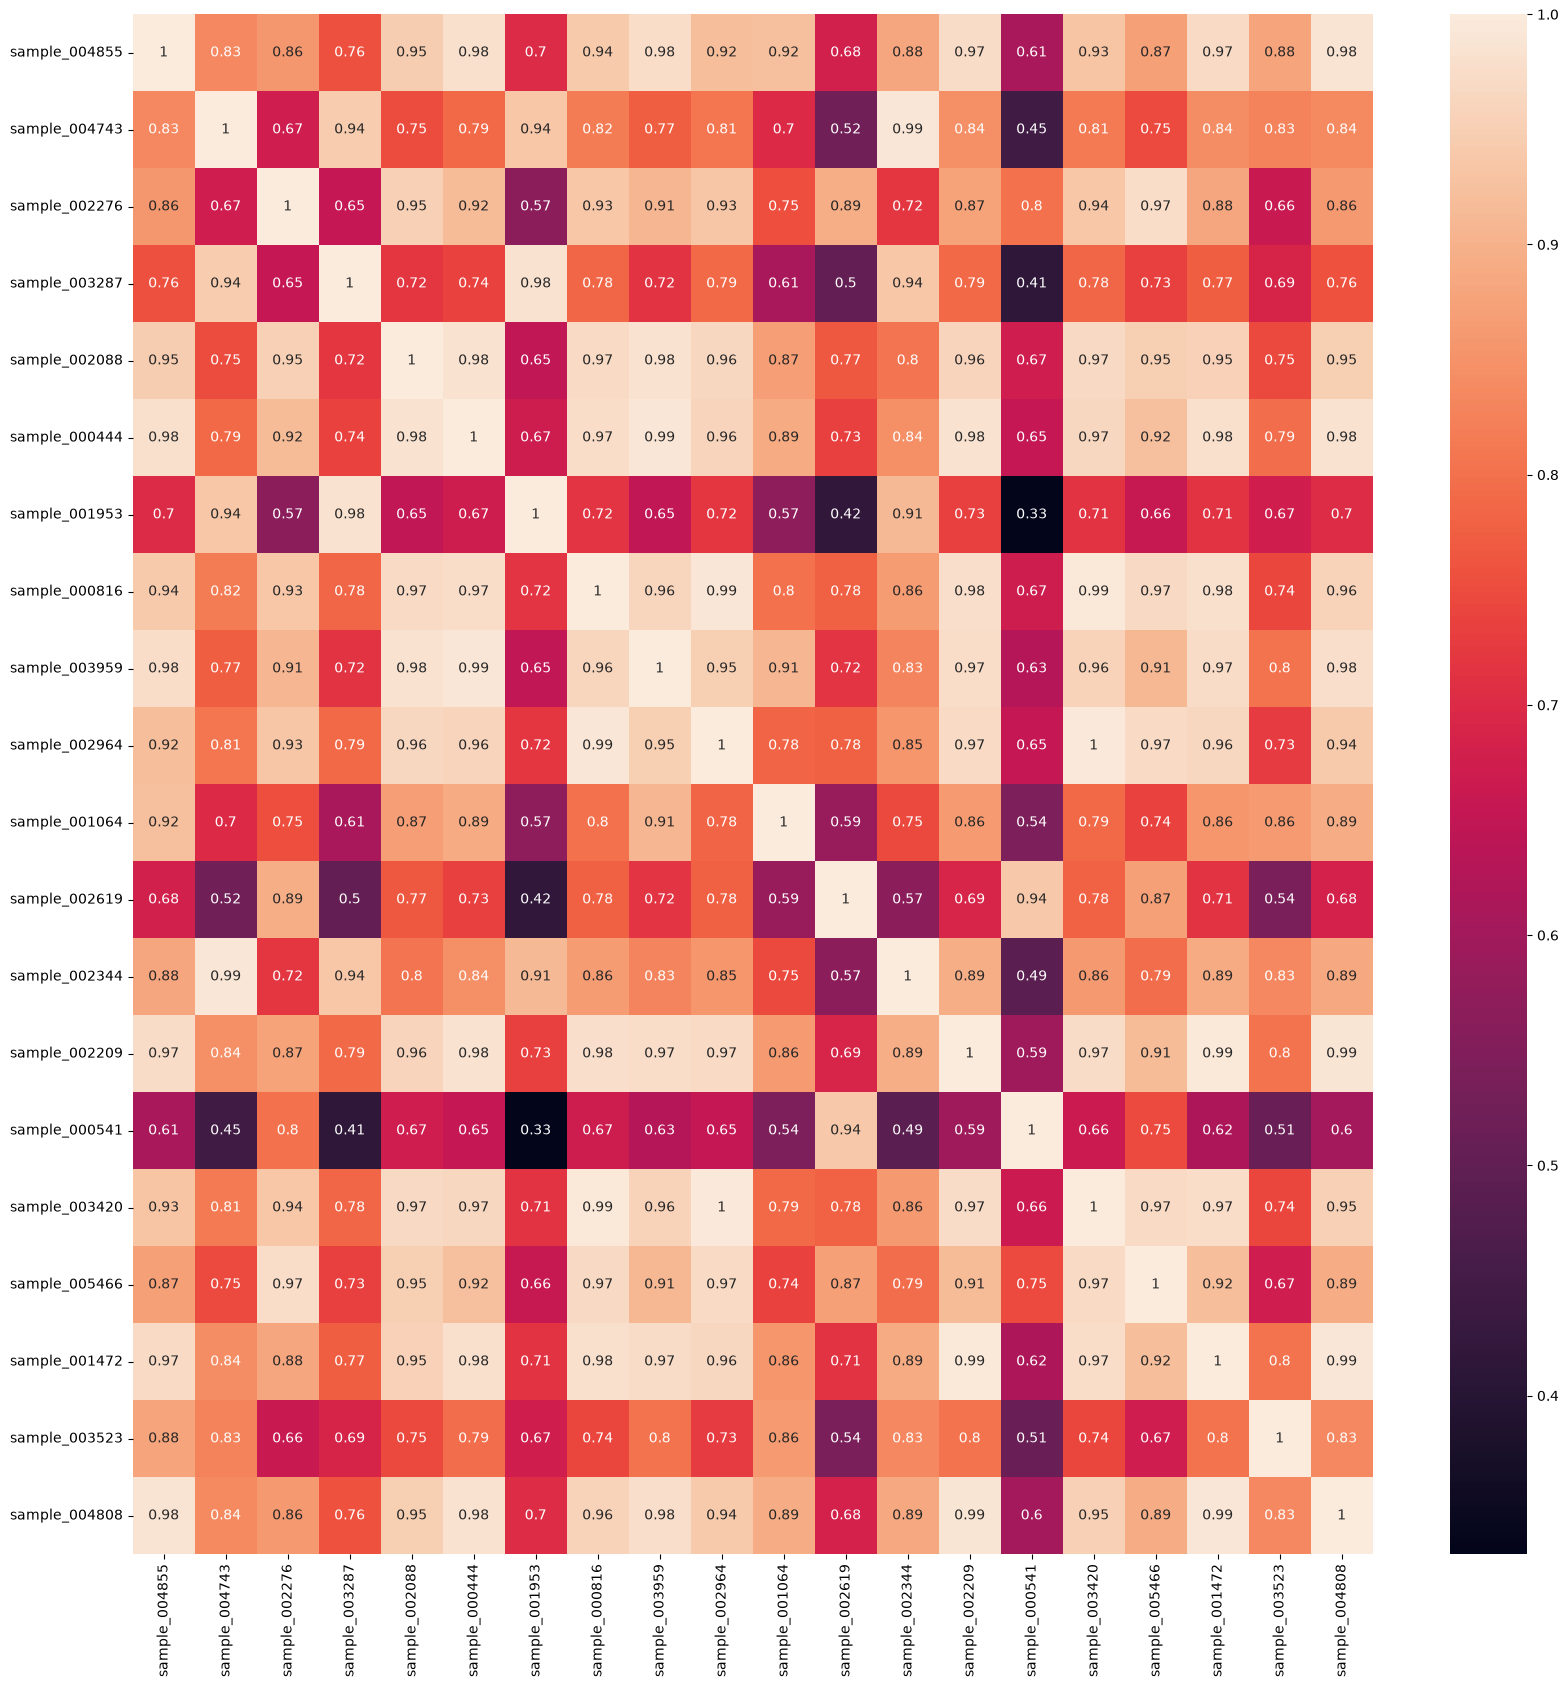

In [77]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 20))
sns.heatmap(
    data=cos_matrix,
    xticklabels=selected_folders,
    yticklabels=selected_folders,
    annot=True,
)
plt.show()

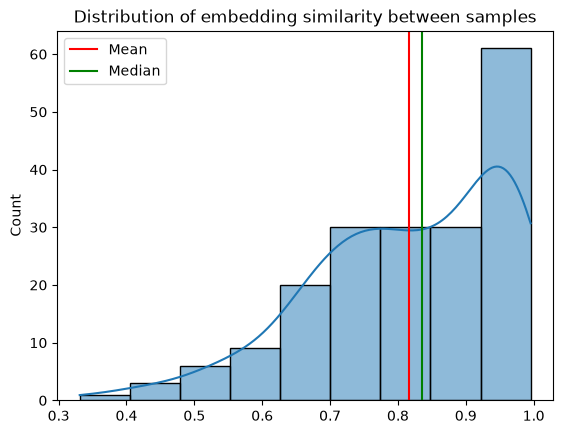

In [101]:
corrs_flat = torch.tril(cos_matrix, diagonal=-1)
corrs_flat = corrs_flat.flatten()
corrs_flat = corrs_flat[corrs_flat != 0]
mean, median = corrs_flat.mean(), corrs_flat.median()
sns.histplot(corrs_flat, kde=True)
plt.axvline(x=mean, color="red", label="Mean")
plt.axvline(x=median, color="green", label="Median")
plt.title("Distribution of embedding similarity between samples")
plt.legend()
plt.show()

### Evaluate recontruction

In [10]:
def evaluate_mesh_reconstruction(
    mesh_dict: dict[str, trimesh.Trimesh],
    model,
    checkpoint,
    config,
    device,
    mask_ratio=0.5,
):
    """
    Given a STL Dict, calculates reconstruction MSE and R2 scores.
    Args:
        mesh_dict: Dict of STL meshes.
        model: Loaded GAOTBackbone model.
        checkpoint: The loaded checkpoint dictionary.
        config: Loaded config object.
        device: PyTorch device ('cuda' or 'cpu').
        mask_ratio: Fraction of geometry to mask (0.0 for full reconstruction, 0.5 for infilling).
    """
    # 1. Initialize LossComputer to get the recon projection head & calibration buffers
    recon_dim = compute_raw_geo_stats_dim(config.tokenizer.geo_embed)
    loss_computer = LossComputer(
        config.train.loss,
        token_dim=config.tokenizer.latent.token_dim,
        recon_target_dim=recon_dim,
    ).to(device)

    if "loss_computer_state_dict" in checkpoint:
        loss_computer.load_state_dict(
            checkpoint["loss_computer_state_dict"], strict=False
        )
    loss_computer.eval()
    model.eval()

    # 2. Initialize preprocessing tools
    preprocessor = MeshPreprocessor(config.input)
    sampler = SurfaceSampler(config.input)

    results = {}

    for sample, mesh in mesh_dict.items():
        try:
            # Preprocess and sample
            preprocessed, sampled, features = preprocess_sample_and_build_features(
                preprocessor, sampler, mesh
            )
            points_t, features_t, normals_t, curvature_t = (
                extract_points_features_normals_curvature_tensors(
                    features=features, sampled=sampled
                )
            )
            # 3. Create evaluation mask (if mask_ratio > 0)
            B, T = points_t.shape[0], model.encoder.num_tokens
            mask = None
            if mask_ratio > 0.0:
                n_mask = int(T * mask_ratio)
                mask = torch.zeros(B, T, dtype=torch.bool, device=device)
                mask[0, torch.randperm(T)[:n_mask]] = True

            # 4. Model forward pass
            with torch.no_grad():
                output = model.forward_tokens(
                    points=points_t,
                    features=features_t,
                    normals=normals_t,
                    curvature=curvature_t,
                    mask=mask,
                )

                # Get the real targets and predict the reconstructed stats
                target_raw = output["raw_geo_stats"]
                # Z-score normalize targets (uses calibration buffers from training)
                target_norm = loss_computer._maybe_normalize_target(target_raw)
                predicted_norm = loss_computer.recon_proj(output["token_embeddings"])

                # If masked, only evaluate on the unseen masked parts
                if mask is not None:
                    eval_pred = predicted_norm[mask]
                    eval_tgt = target_norm[mask]
                else:
                    eval_pred = predicted_norm
                    eval_tgt = target_norm

                # 5. Compute metrics
                mse = torch.mean((eval_pred - eval_tgt) ** 2).item()

                # R2 (Coefficient of Determination)
                ss_res = torch.sum((eval_pred - eval_tgt) ** 2).item()
                ss_tot = torch.sum((eval_tgt - torch.mean(eval_tgt)) ** 2).item()
                r2 = 1.0 - (ss_res / (ss_tot + 1e-12))
                mae = torch.mean(torch.abs((eval_pred - eval_tgt) / (eval_tgt + 1e-8)))

            results[sample] = {"mse": mse, "r2": r2}
            print(f"Mesh: {os.path.basename(sample)}")
            print(f"  -> Reconstruction MAE (lower is better): {mae:.5f}")
            print(f"  -> Reconstruction MSE (lower is better): {mse:.5f}")
            print(f"  -> Reconstruction R² Score (close to 1.0 is better): {r2:.3f}\n")

        except Exception as e:
            print(f"Error processing {sample}: {e}\n")

    return results

In [11]:
# Run full autoencoder reconstruction evaluation (0% mask)
print("--- RUNNING 0% MASK AUTOENCODER EVALUATION ---")
ae_results = evaluate_mesh_reconstruction(
    mesh_dict, model, checkpoint, config, device, mask_ratio=0.0
)

# Run standard infilling evaluation (50% mask)
print("--- RUNNING 50% MASK INFILL EVALUATION ---")
infill_results = evaluate_mesh_reconstruction(
    mesh_dict, model, checkpoint, config, device, mask_ratio=0.5
)

print("--- RUNNING 25% MASK INFILL EVALUATION ---")
infill_results = evaluate_mesh_reconstruction(
    mesh_dict, model, checkpoint, config, device, mask_ratio=0.25
)

print("--- RUNNING 80% MASK INFILL EVALUATION ---")
infill_results = evaluate_mesh_reconstruction(
    mesh_dict, model, checkpoint, config, device, mask_ratio=0.8
)

--- RUNNING 0% MASK AUTOENCODER EVALUATION ---
Mesh: sample_004855
  -> Reconstruction MAE (lower is better): 1.25147
  -> Reconstruction MSE (lower is better): 0.02101
  -> Reconstruction R² Score (close to 1.0 is better): 0.970

Mesh: sample_004743
  -> Reconstruction MAE (lower is better): 1.30520
  -> Reconstruction MSE (lower is better): 0.02141
  -> Reconstruction R² Score (close to 1.0 is better): 0.969

Mesh: sample_002276
  -> Reconstruction MAE (lower is better): 1.08526
  -> Reconstruction MSE (lower is better): 0.01829
  -> Reconstruction R² Score (close to 1.0 is better): 0.974

Mesh: sample_003287
  -> Reconstruction MAE (lower is better): 1.29475
  -> Reconstruction MSE (lower is better): 0.01745
  -> Reconstruction R² Score (close to 1.0 is better): 0.974

Mesh: sample_002088
  -> Reconstruction MAE (lower is better): 1.14733
  -> Reconstruction MSE (lower is better): 0.02194
  -> Reconstruction R² Score (close to 1.0 is better): 0.969

Mesh: sample_000444
  -> Reconstr

In [139]:
model(points_t, features_t, normals_t, curvature_t)

{'token_embeddings': tensor([[[-0.8769,  1.1463,  0.4568,  ..., -0.6530,  0.2444, -0.0915],
          [-0.4000,  0.0591,  0.7905,  ..., -1.4913, -0.0538, -0.1721],
          [-0.7872,  0.2206,  0.0932,  ..., -0.7043,  0.7516, -0.0748],
          ...,
          [-0.6409,  0.6989,  0.4684,  ..., -1.1311,  0.1640,  0.4380],
          [-0.0278,  1.5684,  0.6293,  ..., -0.4907,  0.4943, -0.2391],
          [-0.8839,  0.1452,  0.1823,  ..., -0.6595,  0.4561,  0.5837]]],
        device='cuda:0', grad_fn=<ViewBackward0>),
 'pooled_embedding': tensor([[-0.1195, -0.0765,  0.0211, -0.0133, -0.0036,  0.1208,  0.2134, -0.2220,
          -0.2559, -0.0216,  0.0411,  0.0064,  0.0627, -0.1136,  0.0963,  0.0383,
          -0.0023, -0.0196,  0.0368,  0.1303, -0.1325, -0.0171, -0.1993, -0.0796,
          -0.0927,  0.0397,  0.1912, -0.0274,  0.1239, -0.0578, -0.0893, -0.0671,
          -0.1809,  0.1010, -0.0209, -0.0738,  0.0193,  0.1451,  0.0265, -0.0945,
          -0.0276,  0.0597,  0.0374,  0.0266,  0.0